<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [12]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [13]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [15]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [14]:
Graph1

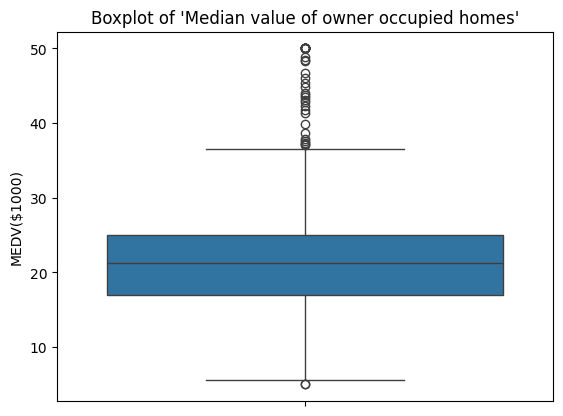

In [16]:
#For the "Median value of owner-occupied homes" provide a boxplot

ax = sns.boxplot(y='MEDV', data = boston_df)
pyplot.title("Boxplot of 'Median value of owner occupied homes'")
pyplot.ylabel('MEDV($1000)')
pyplot.show()

# The boxplot displays the median, quartiles (25th and 75th percentiles), whiskers (range excluding outliers), and any outliers in 
# home prices.I t quickly summarizes the central tendency and spread of house prices and highlights any unusually high or low values.

In [ ]:
Graph2

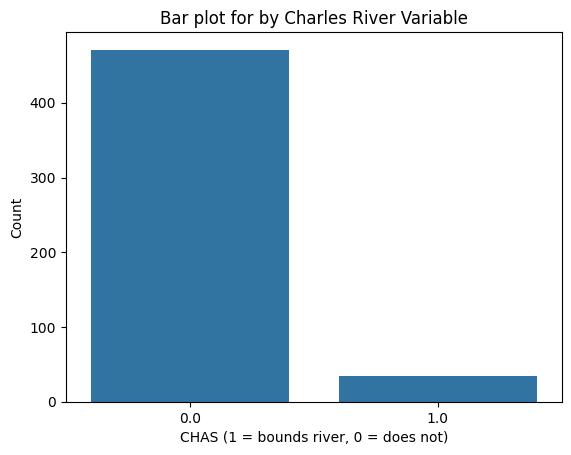

In [17]:
#Provide a  bar plot for the Charles river variable

chas_counts = boston_df['CHAS'].value_counts().reset_index()
chas_counts.columns = ['CHAS', 'count']
sns.barplot(x='CHAS', y='count', data=chas_counts)
pyplot.title('Bar plot for by Charles River Variable')
pyplot.xlabel('CHAS (1 = bounds river, 0 = does not)')
pyplot.ylabel('Count')
pyplot.show()

# It shows the count of the houses which are bounded by the Charles River and the count of the houses which are not bound by the Charles River.

In [ ]:
Graph3

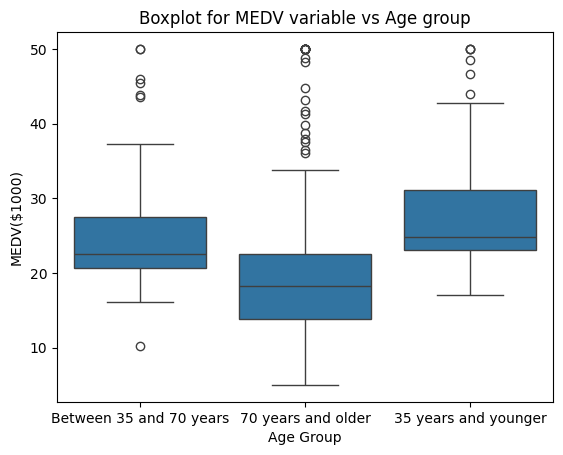

In [18]:
# Provide a boxplot for the MEDV variable vs the AGE variable. 
# (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

boston_df.loc[boston_df['AGE'] <= 35, 'AGE_Group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35) & (boston_df['AGE'] < 70), 'AGE_Group'] = 'Between 35 and 70 years'
boston_df.loc[boston_df['AGE'] >= 70, 'AGE_Group'] = '70 years and older'

sns.boxplot(x='AGE_Group', y='MEDV', data=boston_df)
pyplot.title('Boxplot for MEDV variable vs Age group')
pyplot.xlabel('Age Group')
pyplot.ylabel('MEDV($1000)')
pyplot.show()

# The age is divided into 3 groups with 35 and lower, between 35 and 70 (excluding both limits) and 70 and higher.
# This graph shows the distribution of Median value of occupied homes in different age groups.

In [ ]:
Graph4

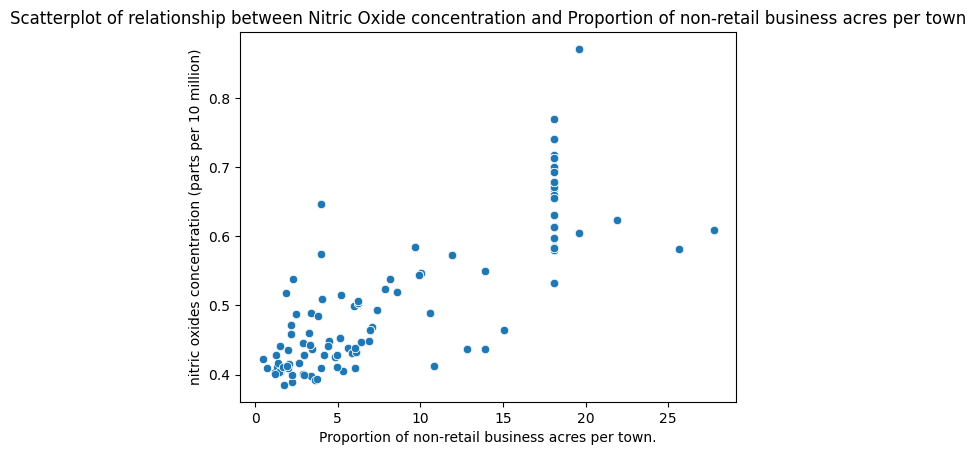

In [19]:
# Provide a scatter plot to show the relationship between Nitric oxide concentrations and 
# the proportion of non-retail business acres per town. What can you say about the relationship?

sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
pyplot.title('Scatterplot of relationship between Nitric Oxide concentration and Proportion of non-retail business acres per town')
pyplot.xlabel('Proportion of non-retail business acres per town.')
pyplot.ylabel('nitric oxides concentration (parts per 10 million)')
pyplot.show()

# This graph shows the relationship between non-retail business area and pollution(Nitric oxide concentration), with each point in the 
# scatter plot representing a town.

In [ ]:
Graph5

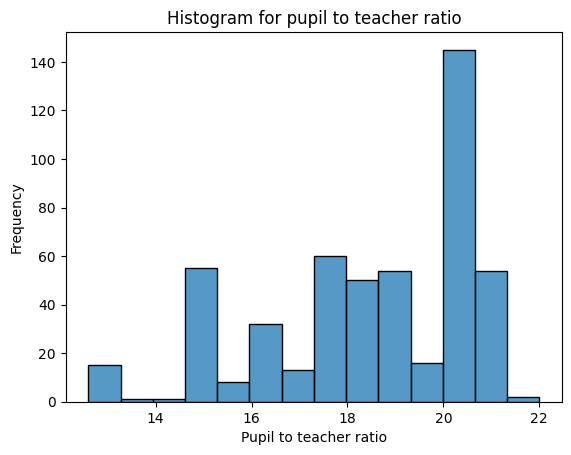

In [20]:
# Create a histogram for the pupil to teacher ratio variable

sns.histplot(x='PTRATIO', data=boston_df)
pyplot.title('Histogram for pupil to teacher ratio')
pyplot.xlabel('Pupil to teacher ratio')
pyplot.ylabel('Frequency')
pyplot.show()

# This shows the pupil-teacher ratio in the town, showing the ratio range and frequency

In [ ]:
Q1

In [ ]:
Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)

Null hypothesis: There is no significant difference in median value of houses bound by the Charles River or not
Alternative hypothesis: There is a significant difference in median value of houses bound by the Charles River or not

In [21]:
scipy.stats.ttest_ind(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                      boston_df[boston_df['CHAS'] == 1]['MEDV'])

TtestResult(statistic=-3.996437466090509, pvalue=7.390623170519905e-05, df=504.0)

In [ ]:
The p-value is 0.000073, which is less than α = 0.05. So we reject the null hypothesis. We can conclude that there is a significant
difference between median value of houses bound by Charles River or not

In [ ]:
Q2

In [ ]:
Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? (ANOVA)

Null hypothesis: AGE_Group values have the same mean MEDV
Alternative hypothesis: Atleast one AGE_Group values have different mean MEDV

In [22]:
medv_35_lower = boston_df[boston_df['AGE_Group'] == '35 years and younger']['MEDV']
medv_between_35_and_70 = boston_df[boston_df['AGE_Group'] == 'Between 35 and 70 years']['MEDV']
medv_70_older = boston_df[boston_df['AGE_Group'] == '70 years and older']['MEDV']

scipy.stats.f_oneway(medv_35_lower, medv_between_35_and_70, medv_70_older)

F_onewayResult(statistic=36.40764999196599, pvalue=1.7105011022702984e-15)

In [ ]:
The p-value is close to 0 and is less than α = 0.05. So we reject the null hypothesis. We can conclude that there is a difference in mean 
values of MEDV for different AGE_Groups

In [ ]:
Q3

In [ ]:
Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? 
(Pearson Correlation)

Null hypothesis: There is no correlation between NOX and INDUS
Alternative hypothesis: There is a correlation between NOX and INDUS

In [23]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])


PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

In [ ]:
The p-value is close to 0 which is less than α = 0.05. So we reject the null hypothesis. We can conclude that there is a correlation 
between Nitric Oxide concentrations and proportion of non-retail business acres per town.

In [ ]:
Q4

In [ ]:
What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes? 
(Regression analysis)

Null hypothesis: There is no impact of DIS on MEDV
Alternative hypothesis: There is an impact of DIS on MEDV

In [24]:
X = boston_df['DIS']
y = boston_df['MEDV']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 23 Jun 2025   Prob (F-statistic):           1.21e-08
Time:                        22:31:09   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
The p-value is close to 0 which is less than α = 0.05. So we reject the null hypothesis. We can conclude that the additional weighted
distance to the five Boston employment centres have an impact on the median value of owner occupied homes.

Correlation coefficient is root(0.062) which is 0.249. Since it is positive and close to 0, DIS and MEDV have a weak positive correlation.

Coefficient is 1.09, which means that as DIS increases by 1, MEDV increases by 1.09.